In [13]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import scanpy as sc
import sys

sys.path.append('/home/lixiangyu/zjx/spark/function/translate/clustering/SpatialGlue/SpatialGlue-main')


device='cuda'

import anndata as ad

sys.path.append('/home/lixiangyu/zjx/spark/function/translate/clustering')
from util import run_leiden,run_louvain

from SpatialGlue.utils import clustering


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# dataset_id='MBCS2'
# # sample_id='H3K4me3_ATAC'
# sample_id='H3K27me3_RNA'
# n_domain=18
# method_list=['MISO','PRESENT','SpatialGlue']
# cluster_types=['mclust','louvain','leiden']


dataset_id='MT'
sample_id='2_RNA'
# sample_id='4_ADT'
n_domain=6
method_list=['MISO','PRESENT','SpatialGlue']
cluster_types=['mclust']


adata=sc.read_h5ad(f'/home/lixiangyu/zjx/spark/function/translate/translate_result_OT/{dataset_id}/{sample_id}.h5ad')

cluster_cols=[]

save_dir=f'./output/{dataset_id}/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [15]:
adata

AnnData object with n_obs × n_vars = 4253 × 23529
    obs: 'orig.ident', 'x', 'y', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
    var: 'var_type'
    uns: 'batch_colors'
    obsm: 'STAGATE', 'X_umap', 'aligned_spatial', 'pca', 'spatial'

In [16]:

for method in method_list:
    if method=='MISO':
        adata_MISO=sc.read_h5ad(f'/home/lixiangyu/zjx/spark/function/translate/clustering/MISO/output/{dataset_id}/{sample_id}.h5ad')
        if 'louvain' in cluster_types or 'leiden' in cluster_types:
            sc.pp.neighbors(adata_MISO,use_rep='miso_emb')
        if 'mclust' in cluster_types:
            clustering(adata_MISO, key='miso_emb', add_key='MISO_mclust', n_clusters=n_domain, method='mclust', use_pca=True)
            adata.obs['MISO_mclust']=adata_MISO.obs['MISO_mclust']
            cluster_cols.append('MISO_mclust')
        
        if 'leiden' in cluster_types:
            adata_MISO = run_leiden(adata_MISO, n_cluster=n_domain, use_rep="miso_emb", key_added="MISO_leiden")
            adata.obs['MISO_leiden']=adata_MISO.obs['MISO_leiden']
            cluster_cols.append('MISO_leiden')
            
        if 'louvain' in cluster_types:
            adata_MISO = run_louvain(adata_MISO, n_cluster=n_domain, use_rep="miso_emb", key_added="MISO_louvain")
            adata.obs['MISO_louvain']=adata_MISO.obs['MISO_louvain']
            cluster_cols.append('MISO_louvain')
        
    if method=='SpatialGlue':
        adata_SpatialGlue=sc.read_h5ad(f"/home/lixiangyu/zjx/spark/function/translate/clustering/SpatialGlue/output/{dataset_id}/{sample_id}.h5ad")
        if 'louvain' in cluster_types or 'leiden' in cluster_types:
            sc.pp.neighbors(adata_SpatialGlue,use_rep='SpatialGlue')
        if 'mclust' in cluster_types:
            clustering(adata_SpatialGlue, key='SpatialGlue', add_key='SpatialGlue_mclust', n_clusters=n_domain, method='mclust', use_pca=True)
            adata.obs['SpatialGlue_mclust']=adata_SpatialGlue.obs['SpatialGlue_mclust']
            cluster_cols.append('SpatialGlue_mclust')
        if 'leiden' in cluster_types:
            adata_SpatialGlue = run_leiden(adata_SpatialGlue, n_cluster=n_domain, use_rep="SpatialGlue", key_added="SpatialGlue_leiden")
            adata.obs['SpatialGlue_leiden']=adata_SpatialGlue.obs['SpatialGlue_leiden']
            cluster_cols.append('SpatialGlue_leiden')
        if 'louvain' in cluster_types:
            adata_SpatialGlue = run_louvain(adata_SpatialGlue, n_cluster=n_domain, use_rep="SpatialGlue", key_added="SpatialGlue_louvain")
            adata.obs['SpatialGlue_louvain']=adata_SpatialGlue.obs['SpatialGlue_louvain']
            cluster_cols.append('SpatialGlue_louvain')
        
       
        
    if method=='PRESENT':
        adata_PRESENT=sc.read_h5ad(f'/home/lixiangyu/zjx/spark/function/translate/clustering/PRESENT/output/{dataset_id}/{sample_id}/adata_output.h5ad')
        if 'louvain' in cluster_types or 'leiden' in cluster_types:
            sc.pp.neighbors(adata_PRESENT,use_rep='embeddings')
        if 'mclust' in cluster_types:
            clustering(adata_PRESENT, key='embeddings', add_key='PRESENT_mclust', n_clusters=n_domain, method='mclust', use_pca=True)
            adata.obs['PRESENT_mclust']=adata_PRESENT.obs['PRESENT_mclust']
            cluster_cols.append('PRESENT_mclust')
        if 'leiden' in cluster_types:
            adata_PRESENT = run_leiden(adata_PRESENT, n_cluster=n_domain, use_rep="embeddings", key_added="PRESENT_leiden")
            adata.obs['PRESENT_leiden']=adata_PRESENT.obs['PRESENT_leiden']
            cluster_cols.append('PRESENT_leiden')
        if 'louvain' in cluster_types:
            adata_PRESENT = run_louvain(adata_PRESENT, n_cluster=n_domain, use_rep="embeddings", key_added="PRESENT_louvain")
            adata.obs['PRESENT_louvain']=adata_PRESENT.obs['PRESENT_louvain']
            cluster_cols.append('PRESENT_louvain')
        
        
        
        
# adata_COSMOS=sc.read_h5ad(f"/home/lixiangyu/zjx/spark/function/translate/clustering/COSMOS/output/{dataset_id}/{sample_id}.h5ad")

fitting ...
  |======================================================================| 100%
fitting ...
  |======================================================================| 100%
fitting ...
  |======================================================================| 100%


In [17]:
sys.path.append('/home/lixiangyu/zjx/spark/function/translate/sc3s/sc3s')
import numpy as np
from _misc import _check_integer_single
from _legacy import convert_dict_into_contigency_matrix, cluster_matrix_agglomerative,cluster_matrix_kmeans
def consensus_vote_from_existing(
    adata,
    cluster_cols,  # 你要参与投票的聚类结果列名列表，如['mclust', 'leiden', 'louvain']
    n_clusters,    # 最终目标簇数（需用户指定，或用SC3的RMT方法估计，见下文备注）
    random_state=None
):
    """
    复用SC3投票聚类逻辑，基于已有多个聚类结果生成共识标签
    
    Parameters
    ----------
    adata : AnnData
        包含多个聚类结果的Annotated data matrix
    cluster_cols : list
        参与投票的聚类列名（如['mclust', 'leiden', 'louvain']）
    n_clusters : int
        最终共识聚类的簇数
    random_state : int, optional
        随机种子（仅k-means时生效，层次聚类无需）
    """
    # 1. 提取并验证用户的聚类结果，转换为SC3要求的dict格式
    trials_dict = {}
    n_cells = adata.n_obs
    for col in cluster_cols:
        # 确保聚类标签是整数类型（处理categorical/string格式）
        labels = adata.obs[col].values
        if not np.issubdtype(labels.dtype, np.integer):
            labels = labels.astype('category').cat.codes  # 转换为0开始的整数
        # SC3的dict格式：key=聚类方法名，value=dict(labels=标签数组)
        # 注：原有SC3的value包含'facility'（簇中心），但投票聚类核心仅需'labels'，故省略
        trials_dict[col] = {'labels': labels}
    
    # 2. 调用SC3函数构建共识矩阵（列联矩阵：统计每对细胞同簇频率）
    # 关键：check_n_clusters=False 跳过簇数一致性检查（用户聚类结果簇数可能不同）
    
    consensus_matrix = convert_dict_into_contigency_matrix(
    # consensus_matrix=convert_dict_into_binary_matrix(
        dict_object=trials_dict,
        true_n_clusters=0,  # 因check_n_clusters=False，该值无效，仅占位
        true_n_cells=n_cells
    )
    print('got consensus_matrix')
    # （可选）若想使用二进制共识矩阵，替换为_cluster.py的convert_dict_into_binary_matrix，逻辑类似
    
    # 3. 调用SC3函数对共识矩阵聚类（复用层次聚类，与SC3论文一致）
    # 若想使用k-means，替换为cluster_matrix_kmeans并传入random_state
    # consensus_labels = cluster_matrix_agglomerative(
    consensus_labels = cluster_matrix_kmeans(
        consensus_matrix=consensus_matrix,
        n_clusters=n_clusters,
        random_state=42
    )
    print('got consensus_labels')
    
    # 4. 将结果存入adata.obs
    adata.obs[f'consensus_vote_{n_clusters}'] = consensus_labels
    adata.obs[f'consensus_vote_{n_clusters}'] = adata.obs[f'consensus_vote_{n_clusters}'].astype('category')
    
    return adata

In [18]:
for col in cluster_cols:
    print(f"处理列: {col}")
    # 步骤1：查看列的原始类型
    print(f"  原始类型: {adata.obs[col].dtype}")
    
    # 步骤2：先将分类类型转为浮点型（解除分类限制），再检查NaN
    # 这一步是解决分类类型无法填充新值的核心
    adata.obs[col] = adata.obs[col].astype('float')
    
    # 步骤3：统计并填充NaN值
    nan_count = adata.obs[col].isna().sum()
    print(f"  NaN值数量: {nan_count}")
    
    if nan_count > 0:
        # 填充NaN为0（也可以改为-1，根据你的业务逻辑调整）
        adata.obs[col] = adata.obs[col].fillna(0)
    
    # 步骤4：安全转换为整数类型
    adata.obs[col] = adata.obs[col].astype(int)
    print(f"  转换后类型: {adata.obs[col].dtype}")

# 2. 运行投票聚类（指定最终簇数n_clusters，如5）
adata = consensus_vote_from_existing(
    adata=adata,
    cluster_cols=cluster_cols,
    n_clusters=n_domain,  # 根据你的数据调整，或用SC3的RMT方法估计（见备注）
    random_state=42
)

# 3. 结果在adata.obs['consensus_vote_5']中

处理列: MISO_mclust
  原始类型: category
  NaN值数量: 0
  转换后类型: int64
处理列: PRESENT_mclust
  原始类型: category
  NaN值数量: 2
  转换后类型: int64
处理列: SpatialGlue_mclust
  原始类型: category
  NaN值数量: 0
  转换后类型: int64
got consensus_matrix
got consensus_labels


In [19]:
for col in cluster_cols:
    adata.obs[col]=adata.obs[col].astype(str)

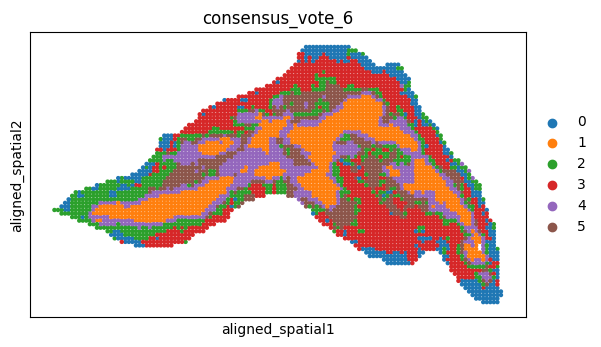

In [20]:
sc.pl.spatial(adata,color=f'consensus_vote_{n_domain}',spot_size=20,basis='aligned_spatial')

In [21]:

    
adata.write(f"{save_dir}/{sample_id}.h5ad")